# Real-Market Implied Volatility — Cleaned Version

Calculated the implied volatility of a live SPY option from Yahoo Finance market data and compares it with Yahoo's reported `impliedVolatility`.

> Note: Yahoo's IV is a vendor-provided value. An exact match is not guaranteed because Yahoo may use different assumptions for rates, dividends, timing, and option conventions.

In [2]:
import math
import time
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import brentq
from scipy.stats import norm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

EASTERN = ZoneInfo("America/New_York")


In [3]:
try:
    from black_scholes import BlackScholesPricer, EuropeanOption, OptionType
except ImportError:
    print("black_scholes module not found. Please ensure it is in the same directory or installed in your environment.")

In [4]:
try:
    from Implied_Volatility_Calculator import ImpliedVolatilityCalculator
except ImportError:
    print("Implied_Volatility_Calculator module not found. Please ensure it is in the same directory or installed in your environment.")

## 1. Black-Scholes-Merton pricing functions

In [5]:
def _d1(S, K, T, r, q, sigma):
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        raise ValueError("S, K, T and sigma must be positive.")
    return (
        math.log(S / K)
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * math.sqrt(T))


def _d2(S, K, T, r, q, sigma):
    return _d1(S, K, T, r, q, sigma) - sigma * math.sqrt(T)


def black_scholes_price(S, K, T, r, q, sigma, option_type="call"):
    """Black-Scholes-Merton price for a European call or put."""
    if T <= 0:
        if option_type.lower() == "call":
            return max(S - K, 0.0)
        return max(K - S, 0.0)

    d1 = _d1(S, K, T, r, q, sigma)
    d2 = d1 - sigma * math.sqrt(T)

    if option_type.lower() == "call":
        return (
            S * math.exp(-q * T) * norm.cdf(d1)
            - K * math.exp(-r * T) * norm.cdf(d2)
        )
    else:
        return (
            K * math.exp(-r * T) * norm.cdf(-d2)
            - S * math.exp(-q * T) * norm.cdf(-d1)
        )


def black_scholes_vega(S, K, T, r, q, sigma):
    """Vega = dPrice/dSigma, with sigma expressed as a decimal."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1 = _d1(S, K, T, r, q, sigma)
    return S * math.exp(-q * T) * norm.pdf(d1) * math.sqrt(T)


def black_scholes_greeks(S, K, T, r, q, sigma, option_type="call"):
    """Return common BSM Greeks for the selected option."""
    d1 = _d1(S, K, T, r, q, sigma)
    d2 = d1 - sigma * math.sqrt(T)

    delta = (
        math.exp(-q * T) * norm.cdf(d1)
        if option_type.lower() == "call"
        else math.exp(-q * T) * (norm.cdf(d1) - 1)
    )

    gamma = (
        math.exp(-q * T) * norm.pdf(d1)
        / (S * sigma * math.sqrt(T))
    )

    vega = black_scholes_vega(S, K, T, r, q, sigma)

    if option_type.lower() == "call":
        theta = (
            -S * math.exp(-q * T) * norm.pdf(d1) * sigma / (2 * math.sqrt(T))
            - r * K * math.exp(-r * T) * norm.cdf(d2)
            + q * S * math.exp(-q * T) * norm.cdf(d1)
        )
    else:
        theta = (
            -S * math.exp(-q * T) * norm.pdf(d1) * sigma / (2 * math.sqrt(T))
            + r * K * math.exp(-r * T) * norm.cdf(-d2)
            - q * S * math.exp(-q * T) * norm.cdf(-d1)
        )

    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta_per_year": theta,
        "theta_per_day": theta / 365.0,
    }


## 2. Brent Implied-volatility solver

In [6]:
def no_arbitrage_bounds(S, K, T, r, q, option_type="call"):
    """European option price bounds under BSM assumptions."""
    if option_type.lower() == "call":
        lower = max(S * math.exp(-q * T) - K * math.exp(-r * T), 0.0)
        upper = S * math.exp(-q * T)
    else:
        lower = max(K * math.exp(-r * T) - S * math.exp(-q * T), 0.0)
        upper = K * math.exp(-r * T)

    return lower, upper


def implied_vol_brent(
    market_price,
    S,
    K,
    T,
    r,
    q=0.0,
    option_type="call",
    lower_sigma=1e-6,
    upper_sigma=5.0,
):
    """Robust IV calculation using Brent's root-finding method."""

    if not np.isfinite(market_price):
        return np.nan

    lower_bound, upper_bound = no_arbitrage_bounds(
        S, K, T, r, q, option_type
    )

    # Small tolerance prevents rejecting a valid quote because of floating-point noise.
    tolerance = 1e-10

    if market_price < lower_bound - tolerance:
        return np.nan

    if market_price > upper_bound + tolerance:
        return np.nan

    call_option = EuropeanOption(strike=K, maturity=T, option_type=OptionType.CALL)

    def objective(sigma):
        bs_pricer = BlackScholesPricer(spot=S, rate=r, volatility=sigma, dividend_yield=q)

        return (
            bs_pricer.price(option=call_option)
            - market_price
        )

    try:
        return brentq(
            objective,
            a=lower_sigma,
            b=upper_sigma,
            xtol=1e-12,
            rtol=1e-12,
            maxiter=200,
        )
    except (ValueError, RuntimeError):
        return np.nan



## 3. Time-to-expiry and market-data helpers

In [7]:
def expiration_datetime(expiration_date):
    """Yahoo supplies the expiration date; use 4:00 PM US/Eastern."""
    expiry = datetime.strptime(expiration_date, "%Y-%m-%d")
    return expiry.replace(
        hour=16,
        minute=0,
        second=0,
        microsecond=0,
        tzinfo=EASTERN,
    )


def calculate_time_to_expiry(expiration_date):
    """Actual time remaining in years using 365-day annualization."""
    now = datetime.now(EASTERN)
    expiry = expiration_datetime(expiration_date)

    seconds = (expiry - now).total_seconds()
    return max(seconds / (365.0 * 24.0 * 60.0 * 60.0), 1e-10)


def get_spot_price(ticker):
    """Get the latest underlying price with a small fallback chain."""
    try:
        spot = ticker.fast_info["lastPrice"]
        if spot is not None and np.isfinite(float(spot)):
            return float(spot)
    except Exception:
        pass

    hist = ticker.history(period="1d")
    if hist.empty:
        raise ValueError("Could not obtain the underlying spot price.")

    return float(hist["Close"].dropna().iloc[-1])


def get_risk_free_rate():
    """Use 13-week T-bill (^IRX) as a transparent short-rate proxy."""
    irx = yf.Ticker("^IRX")

    try:
        value = irx.fast_info["lastPrice"]
        if value is not None and np.isfinite(float(value)):
            return float(value) / 100.0
    except Exception:
        pass

    hist = irx.history(period="5d")
    if hist.empty:
        raise ValueError("Could not obtain ^IRX risk-free-rate proxy.")

    return float(hist["Close"].dropna().iloc[-1]) / 100.0


def get_dividend_yield(ticker):
    """Get Yahoo's current dividend-yield field when available.

    This is an approximation to continuous dividend yield, not a guarantee
    of the exact dividend/carry convention used by Yahoo's IV calculation.
    """
    try:
        info = ticker.info
        q = info.get("dividendYield")

        if q is not None and np.isfinite(float(q)):
            return max(float(q / 100.0), 0.0)
    except Exception:
        pass

    return 0.0


## 4. Download live SPY data

In [8]:
ticker_symbol = "SPY"

print(f"Fetching live data for {ticker_symbol}...")
ticker = yf.Ticker(ticker_symbol)

spot_price = get_spot_price(ticker)
risk_free_rate = get_risk_free_rate()
dividend_yield = get_dividend_yield(ticker)  # Convert percentage to decimal

print(f"Spot price:       ${spot_price:.4f}")
print(f"Risk-free proxy:  {risk_free_rate * 100:.4f}%")
print(f"Dividend yield:   {dividend_yield * 100:.4f}%")

expirations = ticker.options

if not expirations:
    raise ValueError("No option expiration dates returned by Yahoo Finance.")

print(f"Number of expirations available: {len(expirations)}")
print(f"First 10 expirations: {expirations[:10]}")


Fetching live data for SPY...
Spot price:       $770.1900
Risk-free proxy:  3.7570%
Dividend yield:   0.9800%
Number of expirations available: 32
First 10 expirations: ('2026-09-08', '2026-09-09', '2026-09-10', '2026-09-11', '2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25')


## 5. Select an expiration near 30 days

In [9]:
today = datetime.now(EASTERN)

target_expiry = None
best_distance = float("inf")

for exp in expirations:
    expiry_dt = expiration_datetime(exp)
    days_out = (expiry_dt - today).total_seconds() / (24 * 3600)

    # Ignore already-expired dates.
    if days_out <= 0:
        continue

    distance = abs(days_out - 30)

    if distance < best_distance:
        best_distance = distance
        target_expiry = exp

if target_expiry is None:
    raise ValueError("No future expiration date was found.")

T = calculate_time_to_expiry(target_expiry)

print(f"Selected expiry: {target_expiry}")
print(f"Time to expiry:  {T:.6f} years")
print(f"Approx. days:    {T * 365:.3f}")


Selected expiry: 2026-10-09
Time to expiry:  0.089253 years
Approx. days:    32.577


## 6. Download and clean the option chain

In [10]:
chain = ticker.option_chain(target_expiry)
calls = chain.calls.copy()

# Keep only quotes that can form a meaningful bid-ask midpoint.
liquid_calls = calls[
    (calls["bid"] > 0) &
    (calls["ask"] > 0) &
    (calls["ask"] >= calls["bid"]) &
    calls["strike"].notna() &
    calls["impliedVolatility"].notna() &
    (calls["impliedVolatility"] > 0)
].copy()

if liquid_calls.empty:
    raise ValueError(
        "No valid liquid call quotes were returned for the selected expiry."
    )

# Midpoint is the market price used for our IV calculation.
liquid_calls["mid"] = (
    liquid_calls["bid"] + liquid_calls["ask"]
) / 2.0

# Select the strike closest to spot.
liquid_calls["strike_distance"] = (
    liquid_calls["strike"] - spot_price
).abs()

atm_call = liquid_calls.loc[
    liquid_calls["strike_distance"].idxmin()
]

strike = float(atm_call["strike"])
bid = float(atm_call["bid"])
ask = float(atm_call["ask"])
market_price = float(atm_call["mid"])
yahoo_iv = float(atm_call["impliedVolatility"])

print(f"Valid liquid calls: {len(liquid_calls)}")
print()
print("[Selected ATM Call]")
print(f"Strike:       ${strike:.4f}")
print(f"Bid:          ${bid:.4f}")
print(f"Ask:          ${ask:.4f}")
print(f"Midpoint:     ${market_price:.4f}")
print(f"Yahoo IV:     {yahoo_iv * 100:.4f}%")


Valid liquid calls: 136

[Selected ATM Call]
Strike:       $770.0000
Bid:          $11.6400
Ask:          $11.6800
Midpoint:     $11.6600
Yahoo IV:     12.5375%


## 7. Validate the market price before solving for IV

In [11]:
lower_bound, upper_bound = no_arbitrage_bounds(
    spot_price,
    strike,
    T,
    risk_free_rate,
    dividend_yield,
    "call",
)

print("[No-Arbitrage Check]")
print(f"European BSM lower bound: ${lower_bound:.6f}")
print(f"European BSM upper bound: ${upper_bound:.6f}")
print(f"Observed midpoint:        ${market_price:.6f}")

if not (lower_bound <= market_price <= upper_bound):
    raise ValueError(
        "The selected market midpoint violates the BSM price bounds. "
        "Do not calculate IV from this quote."
    )

print("Result: market price is within the BSM bounds.")


[No-Arbitrage Check]
European BSM lower bound: $2.094285
European BSM upper bound: $769.516631
Observed midpoint:        $11.660000
Result: market price is within the BSM bounds.


## 8. Calculate IV using Brent and Newton-Raphson

In [12]:
start = time.perf_counter()

iv_brent = implied_vol_brent(
    market_price=market_price,
    S=spot_price,
    K=strike,
    T=T,
    r=risk_free_rate,
    q=dividend_yield,
    option_type="call",
)

brent_time_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()

call_option = EuropeanOption(strike=strike, maturity=T, option_type=OptionType.CALL)
iv_calculator = ImpliedVolatilityCalculator(spot=spot_price, rate=risk_free_rate, dividend_yield=dividend_yield)

iv_newton = iv_calculator.newton_raphson(option=call_option, market_price=market_price)

newton_time_ms = (time.perf_counter() - start) * 1000

print("[Implied Volatility Results]")
print(f"Brent IV:       {iv_brent * 100:.6f}%")
print(f"Newton IV:      {iv_newton * 100:.6f}%")
print(f"Yahoo IV:       {yahoo_iv * 100:.6f}%")
print()
print(f"Brent time:     {brent_time_ms:.4f} ms")
print(f"Newton time:    {newton_time_ms:.4f} ms")
print()
print(f"Brent vs Yahoo:  {abs(iv_brent - yahoo_iv) * 100:.6f} percentage points")
print(f"Newton vs Yahoo: {abs(iv_newton - yahoo_iv) * 100:.6f} percentage points")


[Implied Volatility Results]
Brent IV:       11.551962%
Newton IV:      11.551962%
Yahoo IV:       12.537496%

Brent time:     8.2672 ms
Newton time:    1.5977 ms

Brent vs Yahoo:  0.985534 percentage points
Newton vs Yahoo: 0.985534 percentage points


## 9. Verify the calculated IV by repricing the option

In [13]:
bs_pricer_1 = BlackScholesPricer(spot=spot_price, rate=risk_free_rate, volatility=iv_brent, dividend_yield=dividend_yield)
calculated_price_brent = bs_pricer_1.price(option=call_option)

bs_pricer_2 = BlackScholesPricer(spot=spot_price, rate=risk_free_rate, volatility=iv_newton, dividend_yield=dividend_yield)
calculated_price_newton = bs_pricer_2.price(option=call_option)

print("[Price Verification]")
print(f"Observed midpoint:       ${market_price:.8f}")
print(f"Price from Brent IV:     ${calculated_price_brent:.8f}")
print(f"Price from Newton IV:    ${calculated_price_newton:.8f}")
print()
print(f"Brent pricing error:     ${abs(calculated_price_brent - market_price):.10f}")
print(f"Newton pricing error:    ${abs(calculated_price_newton - market_price):.10f}")


[Price Verification]
Observed midpoint:       $11.66000000
Price from Brent IV:     $11.66000000
Price from Newton IV:    $11.66000001

Brent pricing error:     $0.0000000000
Newton pricing error:    $0.0000000060


## 10. Calculate Greeks using the calculated IV

In [14]:
delta = bs_pricer_1.delta(option=call_option)
gamma = bs_pricer_1.gamma(option=call_option)
vega = bs_pricer_1.vega(option=call_option)
theta_per_year = bs_pricer_1.theta(option=call_option)

print("[Live-Market Greeks]")
print(f"Delta:          {delta:.6f}")
print(f"Gamma:          {gamma:.6f}")
print(f"Vega:           {vega:.6f}")
print(f"Theta / year:   {theta_per_year:.6f}")
print(f"Theta / day:    {theta_per_year / 252:.6f}")


[Live-Market Greeks]
Delta:          0.537857
Gamma:          0.014926
Vega:           91.290984
Theta / year:   -70.144701
Theta / day:    -0.278352


## 11. Final comparison table

In [15]:
comparison = pd.DataFrame({
    "Metric": [
        "Spot",
        "Strike",
        "Time to expiry (years)",
        "Bid",
        "Ask",
        "Midpoint market price",
        "Risk-free rate",
        "Dividend yield",
        "Yahoo IV",
        "Brent IV",
        "Newton IV",
        "Brent - Yahoo",
        "Newton - Yahoo",
        "Brent repricing error",
        "Newton repricing error",
    ],
    "Value": [
        spot_price,
        strike,
        T,
        bid,
        ask,
        market_price,
        risk_free_rate,
        dividend_yield,
        yahoo_iv,
        iv_brent,
        iv_newton,
        iv_brent - yahoo_iv,
        iv_newton - yahoo_iv,
        calculated_price_brent - market_price,
        calculated_price_newton - market_price,
    ]
})

comparison


,Metric,Value
0,Spot,7.701900e+02
1,Strike,7.700000e+02
2,Time to expiry (years),8.925255e-02
3,Bid,1.164000e+01
4,Ask,1.168000e+01
5,Midpoint market price,1.166000e+01
6,Risk-free rate,3.757000e-02
7,Dividend yield,9.800000e-03
8,Yahoo IV,1.253750e-01
9,Brent IV,1.155196e-01


## Interpretation

### Why our IV may still differ from Yahoo
A remaining difference does **not automatically indicate a coding error**. Possible sources include:

1. Yahoo and this notebook may use different risk-free-rate assumptions.
2. The dividend yield used here is an approximation to continuous dividend yield.
3. Yahoo may use a different time-to-expiry convention.
4. SPY options are American-style while the notebook uses the European BSM model.
5. The midpoint is our chosen market price; Yahoo may use a different option-price input/convention.
6. Market quotes can change between the underlying price and option-chain requests.

In [16]:
bs_pricer_3 = BlackScholesPricer(spot=spot_price, rate=risk_free_rate, volatility=yahoo_iv, dividend_yield=dividend_yield)
yahoo_price = bs_pricer_3.price(option=call_option)

print(f"Market midpoint: ${market_price:.4f}")
print(f"Price using Yahoo IV: ${yahoo_price:.4f}")
print(f"Difference: ${yahoo_price - market_price:.4f}")

Market midpoint: $11.6600
Price using Yahoo IV: $12.5599
Difference: $0.8999


# Analyzing Volatility Skew/Smile

In [17]:
selected_expiry = target_expiry

# Get option chain for the selected expiry
option_chain = ticker.option_chain(selected_expiry)

calls = option_chain.calls.copy()
puts = option_chain.puts.copy()

print(f"Selected Expiry: {selected_expiry}")
print(f"Number of call contracts: {len(calls)}")
print(f"Number of put contracts: {len(puts)}")

Selected Expiry: 2026-10-09
Number of call contracts: 136
Number of put contracts: 121


In [45]:
def clean_option_chain(df):
    df = df[
        (df["bid"] > 0) &
        (df["ask"] > 0) &
        (df["ask"] >= df["bid"])
    ].copy()

    # Midpoint market price
    df["mid_price"] = (df["bid"] + df["ask"]) / 2

    df["relative_spread"] = (
        (df["ask"] - df["bid"])
        / df["mid_price"]
    )

    df = df[df["relative_spread"] < 0.15].copy()

    df = df[df["openInterest"] > 0].copy()

    return df

In [47]:
calls_clean = clean_option_chain(calls)
puts_clean = clean_option_chain(puts)

print(f"Time to maturity: {T:.6f} years")

Time to maturity: 0.089253 years


In [48]:
lower_strike = spot_price * 0.85
upper_strike = spot_price * 1.15

calls_clean = calls_clean[
    (calls_clean["strike"] >= lower_strike) &
    (calls_clean["strike"] <= upper_strike)
].copy()

puts_clean = puts_clean[
    (puts_clean["strike"] >= lower_strike) &
    (puts_clean["strike"] <= upper_strike)
].copy()

print(f"Strikes retained: {len(calls_clean)}")
print(f"Strikes retained: {len(puts_clean)}")

Strikes retained: 111
Strikes retained: 84


In [20]:
calls_clean.columns

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency', 'mid_price'],
      dtype='object')

In [49]:
# Initialize IV calculator using your corrected dividend yield
iv_calc = ImpliedVolatilityCalculator(
    spot=spot_price,
    rate=risk_free_rate,
    dividend_yield=dividend_yield
)

implied_vols = []

for _, row in calls_clean.iterrows():

    K = float(row["strike"])
    market_price = float(row["mid_price"])

    option = EuropeanOption(
        strike=K,
        maturity=T,
        option_type=OptionType.CALL
    )

    try:
        iv = iv_calc.newton_raphson(
            option=option,
            market_price=market_price
        )
    except Exception:
        iv = None

    implied_vols.append(iv)

calls_clean["calculated_iv"] = implied_vols

Sigma became non-positive. Stopping iteration.
Sigma became non-positive. Stopping iteration.
Sigma became non-positive. Stopping iteration.
Sigma became non-positive. Stopping iteration.
Sigma became non-positive. Stopping iteration.


In [50]:
implied_vols = []

for _, row in puts_clean.iterrows():

    K = float(row["strike"])
    market_price = float(row["mid_price"])

    option = EuropeanOption(
        strike=K,
        maturity=T,
        option_type=OptionType.PUT
    )

    try:
        iv = iv_calc.newton_raphson(
            option=option,
            market_price=market_price
        )
    except Exception:
        iv = None

    implied_vols.append(iv)

puts_clean["calculated_iv"] = implied_vols

In [51]:
calls_clean = calls_clean[
    calls_clean["calculated_iv"].notna() &
    np.isfinite(calls_clean["calculated_iv"]) &
    (calls_clean["calculated_iv"] > 0)
].copy()

puts_clean = puts_clean[
    puts_clean["calculated_iv"].notna() &
    np.isfinite(puts_clean["calculated_iv"]) &
    (puts_clean["calculated_iv"] > 0)
].copy()

calls_clean["iv_percent"] = calls_clean["calculated_iv"] * 100
puts_clean["iv_percent"] = puts_clean["calculated_iv"] * 100

In [40]:
repriced_prices = []
pricing_errors = []

for _, row in calls_clean.iterrows():

    K = float(row["strike"])
    iv = float(row["calculated_iv"])

    option = EuropeanOption(
        strike=K,
        maturity=T,
        option_type=OptionType.CALL
    )

    pricer = BlackScholesPricer(
        spot=spot_price,
        rate=risk_free_rate,
        volatility=iv,
        dividend_yield=dividend_yield
    )

    model_price = pricer.price(option)

    repriced_prices.append(model_price)
    pricing_errors.append(model_price - row["mid_price"])

calls_clean["repriced_price"] = repriced_prices
calls_clean["pricing_error"] = pricing_errors
calls_clean["abs_pricing_error"] = calls_clean["pricing_error"].abs()

In [26]:
atm_idx = (calls_clean["strike"] - spot_price).abs().idxmin()

atm_strike = calls_clean.loc[atm_idx, "strike"]
atm_iv = calls_clean.loc[atm_idx, "iv_percent"]

print(f"ATM Strike: {atm_strike}")
print(f"ATM IV: {atm_iv:.4f}%")

ATM Strike: 770.0
ATM IV: 11.5520%


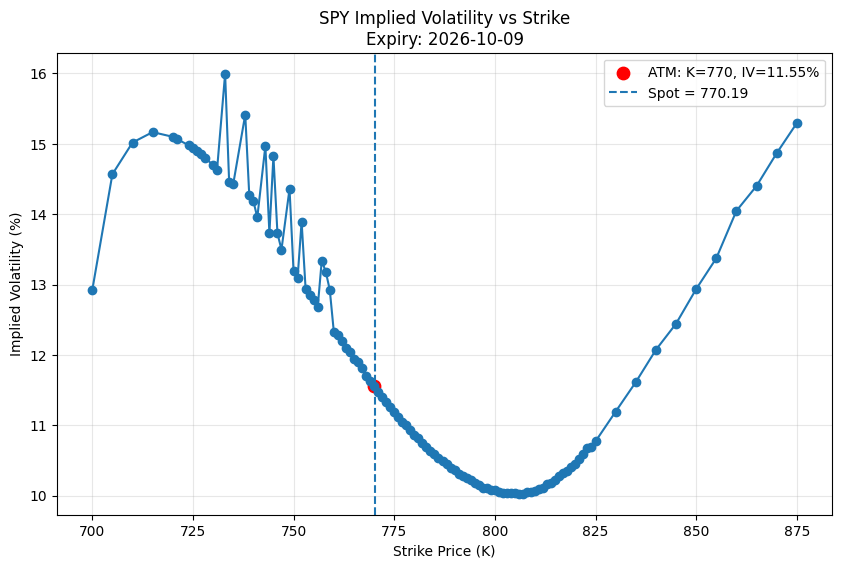

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    calls_clean["strike"],
    calls_clean["iv_percent"],
    marker="o"
)

plt.scatter(
    atm_strike,
    atm_iv,
    s=80,
    c="red",
    label=f"ATM: K={atm_strike:.0f}, IV={atm_iv:.2f}%"
)

plt.axvline(
    spot_price,
    linestyle="--",
    label=f"Spot = {spot_price:.2f}"
)

plt.xlabel("Strike Price (K)")
plt.ylabel("Implied Volatility (%)")
plt.title(f"SPY Implied Volatility vs Strike\nExpiry: {selected_expiry}")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
smile_table = calls_clean[
    [
        "strike",
        "bid",
        "ask",
        "mid_price",
        "impliedVolatility",
        "calculated_iv",
        "repriced_price",
        "abs_pricing_error"
    ]
].copy()

smile_table["calculated_iv"] *= 100

smile_table = smile_table.sort_values("strike")

smile_table

In [42]:
calls_clean["log_moneyness"] = np.log(
    calls_clean["strike"] / spot_price
)

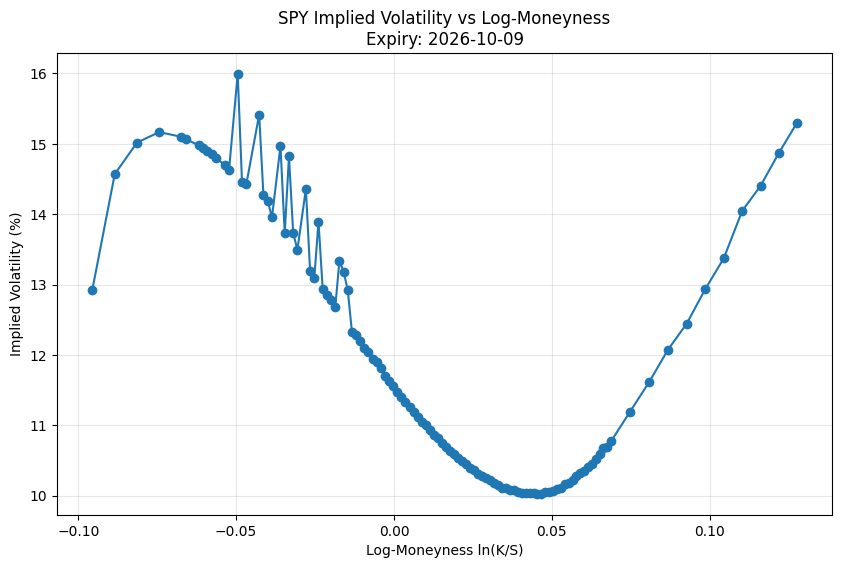

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    calls_clean["log_moneyness"],
    calls_clean["iv_percent"],
    marker="o"
)

plt.xlabel("Log-Moneyness ln(K/S)")
plt.ylabel("Implied Volatility (%)")
plt.title(f"SPY Implied Volatility vs Log-Moneyness\nExpiry: {selected_expiry}")

plt.grid(True, alpha=0.3)
plt.show()

## Calls + Puts IV Plot

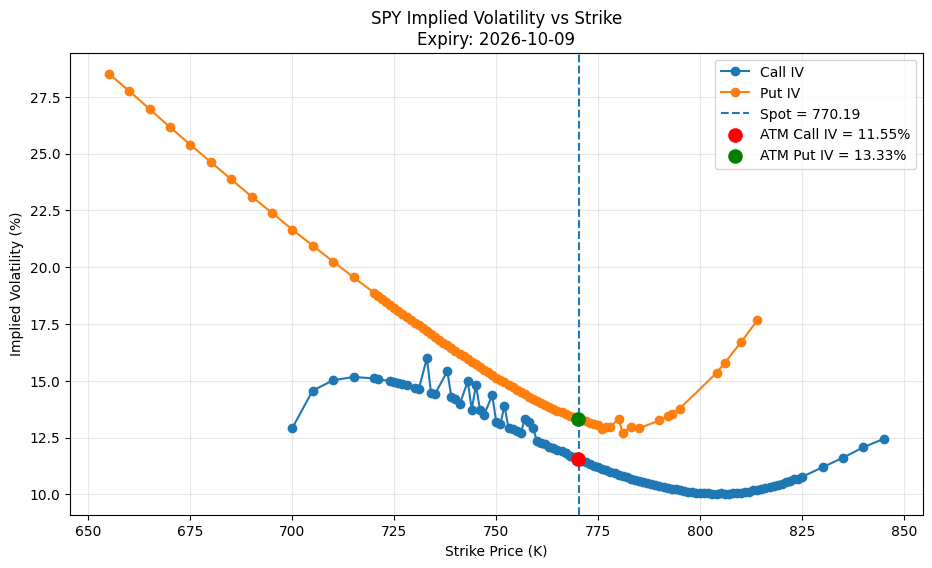

In [55]:
plt.figure(figsize=(11, 6))

plt.plot(
    calls_clean["strike"],
    calls_clean["iv_percent"],
    marker="o",
    label="Call IV"
)

plt.plot(
    puts_clean["strike"],
    puts_clean["iv_percent"],
    marker="o",
    label="Put IV"
)

# Spot price
plt.axvline(
    spot_price,
    linestyle="--",
    label=f"Spot = {spot_price:.2f}"
)

# ATM strike
all_strikes = pd.concat([
    calls_clean[["strike"]],
    puts_clean[["strike"]]
]).drop_duplicates()

atm_strike = all_strikes.iloc[
    (all_strikes["strike"] - spot_price).abs().argsort()[:1]
]["strike"].iloc[0]

# Find ATM IV separately for call and put
atm_call = calls_clean.loc[
    (calls_clean["strike"] - spot_price).abs().idxmin()
]

atm_put = puts_clean.loc[
    (puts_clean["strike"] - spot_price).abs().idxmin()
]

plt.scatter(
    atm_call["strike"],
    atm_call["iv_percent"],
    s=90,
    zorder=5,
    c='red',
    label=f"ATM Call IV = {atm_call['iv_percent']:.2f}%"
)

plt.scatter(
    atm_put["strike"],
    atm_put["iv_percent"],
    s=90,
    zorder=5,
    c='green',
    label=f"ATM Put IV = {atm_put['iv_percent']:.2f}%"
)

plt.xlabel("Strike Price (K)")
plt.ylabel("Implied Volatility (%)")

plt.title(
    f"SPY Implied Volatility vs Strike\n"
    f"Expiry: {selected_expiry}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()